In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('heart_disease_dataset,,,csv.csv')

In [3]:
df.head()

,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Smoking,Alcohol Intake,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,Blood Sugar,Exercise Induced Angina,Chest Pain Type,Heart Disease
0,75,Female,228,119,66,Current,Heavy,1,No,No,Yes,8,119,Yes,Atypical Angina,1
1,48,Male,204,165,62,Current,NaN,5,No,No,No,9,70,Yes,Typical Angina,0
2,53,Male,234,91,67,Never,Heavy,3,Yes,No,Yes,5,196,Yes,Atypical Angina,1
3,69,Female,192,90,72,Current,NaN,4,No,Yes,No,7,107,Yes,Non-anginal Pain,0
4,62,Female,172,163,93,Never,NaN,6,No,Yes,No,2,183,Yes,Asymptomatic,0


In [4]:
df.tail()

,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Smoking,Alcohol Intake,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,Blood Sugar,Exercise Induced Angina,Chest Pain Type,Heart Disease
995,56,Female,269,111,86,Never,Heavy,5,No,Yes,Yes,10,120,No,Non-anginal Pain,1
996,78,Female,334,145,76,Never,NaN,6,No,No,No,10,196,Yes,Typical Angina,1
997,79,Male,151,179,81,Never,Moderate,4,Yes,No,Yes,8,189,Yes,Asymptomatic,0
998,60,Female,326,151,68,Former,NaN,8,Yes,Yes,No,5,174,Yes,Atypical Angina,1
999,53,Male,226,116,82,Current,NaN,6,No,No,Yes,5,161,Yes,Asymptomatic,1


In [5]:
df.shape

(1000, 16)

In [6]:
X = df.drop('Heart Disease',axis = 1)
y = df['Heart Disease']

In [7]:
numerical_features = X.select_dtypes(include=["int64","float64"]).columns
categorical_features = X.select_dtypes(include=["str"]).columns

In [9]:
print(numerical_features,categorical_features)

Index(['Age', 'Cholesterol', 'Blood Pressure', 'Heart Rate', 'Exercise Hours',
       'Stress Level', 'Blood Sugar'],
      dtype='str') Index(['Gender', 'Smoking', 'Alcohol Intake', 'Family History', 'Diabetes',
       'Obesity', 'Exercise Induced Angina', 'Chest Pain Type'],
      dtype='str')


In [10]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
     X,
     y,
     stratify=y,
     random_state=42,
     test_size=0.20
 )


In [11]:
df.isnull().sum()

Age                          0
Gender                       0
Cholesterol                  0
Blood Pressure               0
Heart Rate                   0
Smoking                      0
Alcohol Intake             340
Exercise Hours               0
Family History               0
Diabetes                     0
Obesity                      0
Stress Level                 0
Blood Sugar                  0
Exercise Induced Angina      0
Chest Pain Type              0
Heart Disease                0
dtype: int64

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler , OneHotEncoder

preprocessor = ColumnTransformer(
    transformers = [
        (
            "num",
            Pipeline(
                [
                    ("imputer",SimpleImputer(strategy="median")),
                    ("scaler",StandardScaler())
                ]
            ),
            numerical_features
        ),
         (
                "cat",
            Pipeline(
                [
                    ("imputer",SimpleImputer(strategy="most_frequent")),
                    ("scaler",OneHotEncoder(handle_unknown="ignore"))
                ]
            ),
            categorical_features
        )
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [21]:
print(np.isnan(X_train_processed).sum())

0


In [41]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_processed,y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [54]:
y_pred = model.predict(X_test_processed)
y_pred_proba = model.predict_proba(X_test_processed)[:,1]

In [55]:
from sklearn.metrics import ConfusionMatrixDisplay,classification_report,accuracy_score,precision_score,recall_score,f1_score

In [56]:
print("accuracy:",accuracy_score(y_test,y_pred))
print("precision:",precision_score(y_test,y_pred))
print("recall:",recall_score(y_test,y_pred))
print("f1:",f1_score(y_test,y_pred))
print("Classification report:",classification_report(y_test,y_pred))

accuracy: 0.86
precision: 0.8472222222222222
recall: 0.782051282051282
f1: 0.8133333333333334
Classification report:               precision    recall  f1-score   support

           0       0.87      0.91      0.89       122
           1       0.85      0.78      0.81        78

    accuracy                           0.86       200
   macro avg       0.86      0.85      0.85       200
weighted avg       0.86      0.86      0.86       200



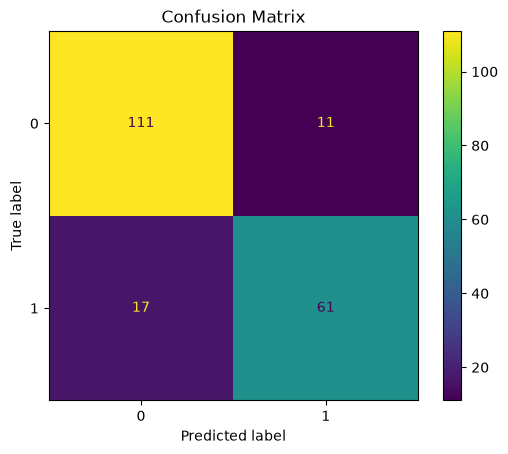

In [57]:
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)
plt.title("Confusion Matrix")
plt.show()

In [58]:
print(y_pred_proba)

[9.65757671e-01 2.65552206e-02 4.50378332e-01 1.58466334e-03
 9.61464974e-01 5.76561248e-02 9.69933674e-01 8.77840879e-01
 2.02401974e-03 1.74489391e-01 2.14756044e-01 1.64733593e-02
 5.93283956e-02 2.03169199e-04 2.76744545e-01 8.72294307e-01
 9.97969905e-01 4.88708004e-02 4.75614250e-05 9.50003184e-01
 2.85550343e-01 1.14819534e-02 9.91885837e-01 1.63266926e-03
 9.15879660e-01 1.07846231e-02 2.39190844e-01 2.24325217e-01
 8.39032413e-03 5.29473258e-02 2.52632007e-03 1.02197329e-02
 4.95262804e-02 7.91777748e-01 2.98299481e-03 5.23608536e-03
 1.53661935e-03 2.12518523e-01 9.18325800e-01 3.48254844e-01
 6.15498469e-02 7.35541776e-01 8.85756866e-01 7.95577912e-04
 9.98119830e-01 3.09890114e-03 2.44692573e-01 2.63395363e-01
 6.24667831e-01 9.13021756e-01 9.93273575e-01 9.94933449e-01
 6.57365539e-01 2.41519368e-03 8.30708421e-01 5.38250805e-03
 2.67007307e-01 2.41848045e-01 1.73897694e-01 5.62560488e-04
 4.97428436e-01 2.61872025e-01 8.57975305e-02 9.88945387e-01
 9.08800698e-02 9.776611

AUC_SCORE: 0.9510298444724674


Text(0.5, 0, 'False positive rates')

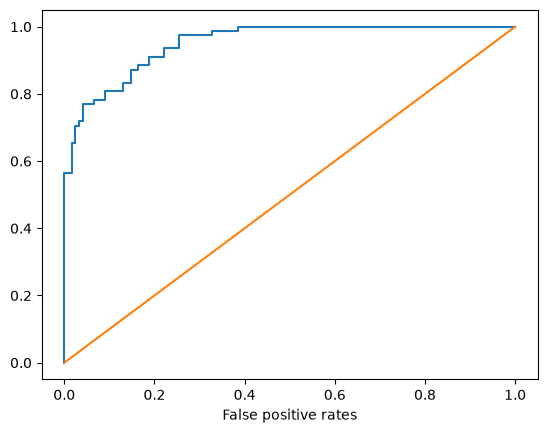

In [71]:
from sklearn.metrics import roc_curve,roc_auc_score

fpr,tpr,thresholds = roc_curve(y_test,y_pred_proba)
auc_score = roc_auc_score(y_test,y_pred_proba)

print("AUC_SCORE:",auc_score)


plt.plot(fpr,tpr,label=f"AUC = {auc_score:.2f}")
plt.plot([0,1],[0,1])
plt.xlabel("False positive rates")

Text(0.5, 0, 'False positive rates')

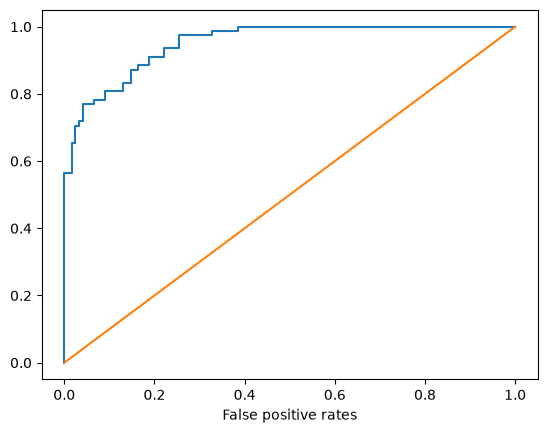

In [70]:
plt.plot(fpr,tpr,label=f"AUC = {auc_score:.2f}")
plt.plot([0,1],[0,1])
plt.xlabel("False positive rates")